# Week 10 — Day 4: Transfer Learning
**Date:** 2026-06-11 | **Mode:** Campus | **Phase 3 — Classic CNN Architectures**

## Today's Agenda
1. What is Transfer Learning and why does it work?
2. Feature Extraction vs Fine-tuning — when to use each
3. Layer freezing strategies
4. Discriminative learning rates (different LR per layer group)
5. Learning rate warm-up
6. Practical demo: ResNet-18, feature extraction vs fine-tuning on 5-class data
7. Domain adaptation overview

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
torch.manual_seed(42)

Device: cpu


## 1. What is Transfer Learning and Why Does It Work?

### The Intuition

Training a deep network from scratch requires:
- **Millions of labelled images** (ImageNet has 1.2M)
- **Weeks of GPU time** (ResNet-50 on ImageNet ≈ 90 GPU-hours)
- **Large batches** for BatchNorm to work correctly

Transfer learning answers: *Can we reuse what a network already learned?*

### What Does a CNN Actually Learn?

Visualisation studies (Zeiler & Fergus, 2013) showed that CNN layers learn in a hierarchy:

```
Layer 1–2  →  edges, colours, simple textures  (generic — same in ANY dataset)
Layer 3–4  →  shapes, corners, object parts    (somewhat generic)
Layer 5+   →  class-specific patterns           (dataset-specific)
```

**Key insight:** Early layers learn universal visual features.
If your target task involves natural images, these early features are **immediately useful**,
regardless of whether the source task was cats vs dogs or plants vs cars.

### Source Task → Target Task

```
Source:  ImageNet (1.2M images, 1000 classes)
              ↓   pretrain
         Weights W* = [W₁, W₂, ..., W_n]   ← stored representations
              ↓   transfer
Target:  Your dataset (500 images, 5 classes)
         Initialise with W*, adapt to new task
```

**Why it works:** The network has already learned to extract meaningful features.
Your small dataset only needs to teach the final layers *how to combine* them.

## 2. Feature Extraction vs Fine-tuning

### Strategy 1: Feature Extraction (Frozen Backbone)

```
Input → [Frozen Conv Layers] → [New FC Head] → Output
              ↑                      ↑
         no gradient           gradient flows
         (requires_grad=False) (requires_grad=True)
```

- Freeze **all** pretrained layers
- Replace the final FC layer with a new one matching your class count
- Only train the new head

**When to use:**
- Very small target dataset (< 500 images per class)
- Target domain is similar to source domain (e.g., natural photos → plant photos)
- Fast — only one small layer trains

### Strategy 2: Fine-tuning (Partial or Full Unfreeze)

```
Input → [Frozen Early] → [Unfrozen Late Layers] → [New FC Head] → Output
              ↑                    ↑                     ↑
         no gradient         gradient flows         gradient flows
                             (small LR)             (larger LR)
```

- Unfreeze the **last few conv blocks** in addition to the head
- Use a **smaller learning rate** for pretrained layers (avoid destroying learned features)

**When to use:**
- Medium dataset (1k–10k images)
- Target domain differs from source (e.g., ImageNet → medical X-rays)

### Strategy 3: Full Fine-tuning

- Unfreeze **everything**, train end-to-end with a small global LR
- Use when you have a large target dataset and enough compute

### Decision Guide

| Target dataset size | Similar to ImageNet? | Strategy |
|--------------------|---------------------|---------|
| Small (<1k)         | Yes                  | Feature extraction |
| Small (<1k)         | No                   | Fine-tune last 1–2 layers |
| Medium (1k–10k)     | Yes/No               | Fine-tune last block |
| Large (>10k)        | Yes/No               | Full fine-tuning |

In [2]:
# Load ResNet-18 architecture (weights=None for offline execution)
# In practice: weights=models.ResNet18_Weights.IMAGENET1K_V1 downloads ImageNet weights

backbone = models.resnet18(weights=None)
print("ResNet-18 layer groups:")
for name, module in backbone.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<12}  {n_params:>9,} params")
print(f"\nTotal: {sum(p.numel() for p in backbone.parameters()):,} parameters")

ResNet-18 layer groups:
  conv1             9,408 params
  bn1                 128 params
  relu                  0 params
  maxpool               0 params
  layer1          147,968 params
  layer2          525,568 params
  layer3        2,099,712 params
  layer4        8,393,728 params
  avgpool               0 params
  fc              513,000 params

Total: 11,689,512 parameters


In [3]:
# ── Strategy 1: Feature Extraction ──────────────────────────────────────────
# Step 1: Freeze ALL pretrained layers
for param in backbone.parameters():
    param.requires_grad = False

# Step 2: Replace final FC with a new trainable head (5 classes)
NUM_CLASSES = 5
in_features = backbone.fc.in_features           # 512 for ResNet-18
backbone.fc = nn.Linear(in_features, NUM_CLASSES)  # only this is trainable

# Verify: only FC is trainable
trainable = [(n, p.shape) for n, p in backbone.named_parameters() if p.requires_grad]
frozen    = sum(1 for p in backbone.parameters() if not p.requires_grad)
print(f"Trainable layers: {len(trainable)}")
print(f"  → {trainable}")
print(f"Frozen parameters: {frozen}")

model_feat_extract = backbone.to(device)
params_trainable = sum(p.numel() for p in model_feat_extract.parameters() if p.requires_grad)
print(f"\nTrainable parameter count: {params_trainable:,}  (vs 11M total)")

Trainable layers: 2
  → [('fc.weight', torch.Size([5, 512])), ('fc.bias', torch.Size([5]))]
Frozen parameters: 60

Trainable parameter count: 2,565  (vs 11M total)


In [4]:
# ── Strategy 2: Fine-tuning — unfreeze the last residual block + FC ─────────
backbone2 = models.resnet18(weights=None)

# First freeze everything
for param in backbone2.parameters():
    param.requires_grad = False

# Then selectively UNFREEZE layer4 (last residual block) and FC
for param in backbone2.layer4.parameters():
    param.requires_grad = True

# Replace FC head
backbone2.fc = nn.Linear(backbone2.fc.in_features, NUM_CLASSES)

model_finetune = backbone2.to(device)

trainable_ft = [(n, p.shape) for n, p in model_finetune.named_parameters() if p.requires_grad]
params_ft     = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)
print(f"Fine-tuning trainable params: {params_ft:,}")
print(f"Unfrozen layer groups:")
for n, _ in trainable_ft[:6]:
    print(f"  {n}")
if len(trainable_ft) > 6:
    print(f"  ... and {len(trainable_ft)-6} more")

Fine-tuning trainable params: 8,396,293
Unfrozen layer groups:
  layer4.0.conv1.weight
  layer4.0.bn1.weight
  layer4.0.bn1.bias
  layer4.0.conv2.weight
  layer4.0.bn2.weight
  layer4.0.bn2.bias
  ... and 11 more


## 3. Discriminative Learning Rates

### The Problem with a Single LR for Fine-tuning

If we use the **same** learning rate for all unfrozen layers:
- High LR → **catastrophic forgetting**: early layers drift away from good ImageNet features
- Low LR → **slow convergence**: later task-specific layers learn too slowly

### Solution: Different LR per Layer Group

Inspired by the ULMFiT paper (Howard & Ruder, 2018):

```
Layer Group         LR
──────────────────────────────────────
layer1 (early)      base_lr / 100  = 1e-5
layer2              base_lr / 10   = 1e-4
layer3              base_lr / 3    = 3.3e-4
layer4 (late)       base_lr        = 1e-3
FC head             base_lr * 3    = 3e-3
```

The early layers are already good — don't disturb them.
The late layers and head need to adapt the most.

In [5]:
# Discriminative learning rates using PyTorch parameter groups
backbone3 = models.resnet18(weights=None)
backbone3.fc = nn.Linear(backbone3.fc.in_features, NUM_CLASSES)

base_lr = 1e-3

param_groups = [
    {'params': backbone3.layer1.parameters(), 'lr': base_lr / 100},
    {'params': backbone3.layer2.parameters(), 'lr': base_lr / 10},
    {'params': backbone3.layer3.parameters(), 'lr': base_lr / 3},
    {'params': backbone3.layer4.parameters(), 'lr': base_lr},
    {'params': backbone3.fc.parameters(),     'lr': base_lr * 3},
]

# Stem (conv1, bn1) — very small LR
param_groups.insert(0, {
    'params': list(backbone3.conv1.parameters()) +
              list(backbone3.bn1.parameters()),
    'lr': base_lr / 1000
})

optimizer_disc = optim.Adam(param_groups)

print("Discriminative learning rates:")
layer_names = ['stem', 'layer1', 'layer2', 'layer3', 'layer4', 'fc_head']
for name, pg in zip(layer_names, optimizer_disc.param_groups):
    n = sum(p.numel() for p in pg['params'])
    print(f"  {name:<10}  lr={pg['lr']:.2e}   params={n:,}")

Discriminative learning rates:
  stem        lr=1.00e-06   params=9,536
  layer1      lr=1.00e-05   params=147,968
  layer2      lr=1.00e-04   params=525,568
  layer3      lr=3.33e-04   params=2,099,712
  layer4      lr=1.00e-03   params=8,393,728
  fc_head     lr=3.00e-03   params=2,565


## 4. Learning Rate Warm-up

### Why Warm-up?

At the very start of training:
- The new FC head has **random weights** — large, noisy gradients
- If LR is high from step 0, these noisy gradients can corrupt the pretrained backbone

**Warm-up:** start with a very small LR, then ramp up to the target LR over the first few epochs.

```
LR
 ↑
 │         ╭───────────────  target LR
 │        /
 │       /   warm-up (e.g. 5 epochs)
 │──────/
 │
 └──────────────────────────────── epoch
   0    5
```

### Common Warm-up Schedules

| Schedule | Description |
|----------|-------------|
| Linear warm-up | LR = target_lr × (epoch / warmup_epochs) |
| Cosine warm-up | Smooth cosine ramp |
| Warm-up + cosine decay | Most common in modern training |

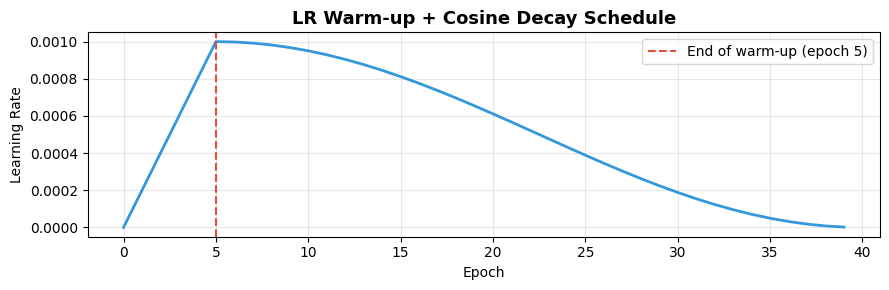

Peak LR: 0.001000  |  Final LR: 0.000002


In [6]:
# LR Warm-up + Cosine Decay scheduler demo

def get_lr_schedule(optimizer, warmup_epochs, total_epochs, base_lr):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs               # linear ramp 0 → 1
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay 1 → 0
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Plot the schedule
total_epochs  = 40
warmup_epochs = 5

temp_model = nn.Linear(10, 5)
temp_opt   = optim.Adam(temp_model.parameters(), lr=1e-3)
scheduler  = get_lr_schedule(temp_opt, warmup_epochs, total_epochs, 1e-3)

lrs = []
for _ in range(total_epochs):
    lrs.append(temp_opt.param_groups[0]['lr'])
    temp_opt.step()
    scheduler.step()

plt.figure(figsize=(9, 3))
plt.plot(lrs, color='#3498db', linewidth=2)
plt.axvline(warmup_epochs, color='#e74c3c', linestyle='--', label=f'End of warm-up (epoch {warmup_epochs})')
plt.title('LR Warm-up + Cosine Decay Schedule', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Peak LR: {max(lrs):.6f}  |  Final LR: {lrs[-1]:.6f}")

## 5. Practical Demo — Feature Extraction vs Fine-tuning

We build a **synthetic 5-class image classification** dataset (400 training, 100 val samples)
and compare:

1. **Feat-Ext**: frozen backbone, only head trains
2. **Fine-tune**: last ResNet block + head unfrozen
3. **From scratch**: no pretrained init

Note: Here we use `weights=None` (random init) since we are offline.
In practice with `weights=IMAGENET1K_V1`, fine-tuning would converge much faster
and reach higher accuracy — the core idea is the same.

In [7]:
# Synthetic 5-class dataset (32x32 images, 5 classes)
torch.manual_seed(0)
n_train, n_val = 400, 100
X_tr = torch.randn(n_train, 3, 32, 32); y_tr = torch.randint(0, NUM_CLASSES, (n_train,))
X_vl = torch.randn(n_val,   3, 32, 32); y_vl = torch.randint(0, NUM_CLASSES, (n_val,))

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=100, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=100)

def train_model(model, name, lr=1e-3, n_epochs=6):
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        total = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            total += loss.item()
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        history['loss'].append(total / len(train_loader))
        history['val_acc'].append(correct / n_val * 100)
    print(f"  {name:<22}  final_acc={history['val_acc'][-1]:.1f}%  time={time.time()-t0:.1f}s")
    return history

# Model C: from scratch (all layers random init, all trainable)
scratch_net  = models.resnet18(weights=None)
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, NUM_CLASSES)

print("Training 3 strategies — 6 epochs, 400 train samples")
print("=" * 55)
h_fe  = train_model(model_feat_extract, "Feature Extraction")
h_ft  = train_model(model_finetune,     "Fine-tuning (layer4+FC)")
h_scr = train_model(scratch_net.to(device), "From Scratch")

Training 3 strategies — 6 epochs, 400 train samples


  Feature Extraction      final_acc=19.0%  time=2.4s


  Fine-tuning (layer4+FC)  final_acc=22.0%  time=4.5s


  From Scratch            final_acc=16.0%  time=7.3s


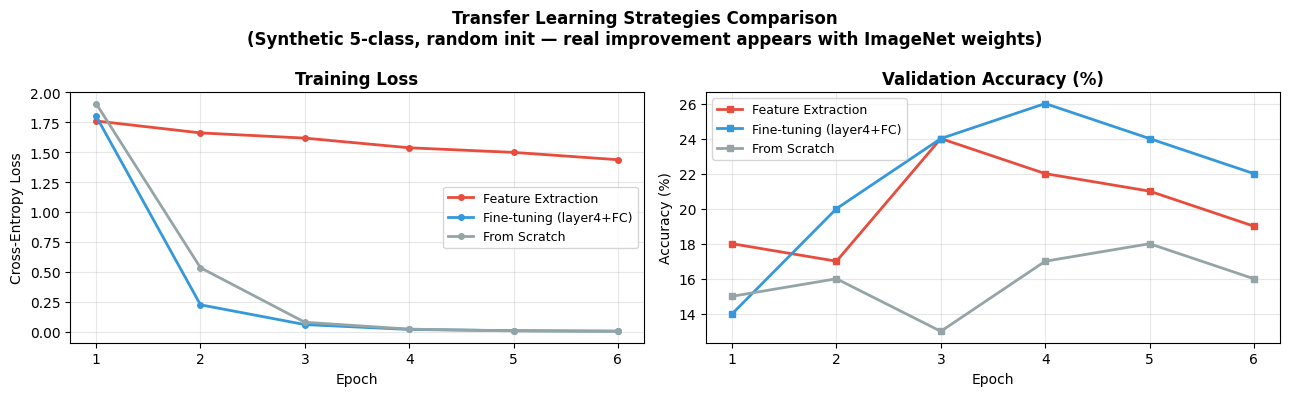

Saved: transfer_learning_comparison.png


In [8]:
# Comparison plot

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {'Feature Extraction': '#e74c3c',
          'Fine-tuning (layer4+FC)': '#3498db',
          'From Scratch': '#95a5a6'}
epochs = range(1, 7)

for label, hist, c in [
    ('Feature Extraction',     h_fe,  '#e74c3c'),
    ('Fine-tuning (layer4+FC)',h_ft,  '#3498db'),
    ('From Scratch',           h_scr, '#95a5a6')]:
    axes[0].plot(epochs, hist['loss'],    label=label, color=c, linewidth=2, marker='o', ms=4)
    axes[1].plot(epochs, hist['val_acc'], label=label, color=c, linewidth=2, marker='s', ms=4)

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Accuracy (%)'],
    ['Cross-Entropy Loss', 'Accuracy (%)']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Transfer Learning Strategies Comparison\n(Synthetic 5-class, random init — real improvement appears with ImageNet weights)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('transfer_learning_comparison.png', dpi=100, bbox_inches='tight')
plt.show(); print("Saved: transfer_learning_comparison.png")

## 6. Domain Adaptation

Sometimes the source and target domains are quite different:

| Source | Target | Gap |
|--------|--------|-----|
| ImageNet (colour photos) | X-Ray (greyscale medical) | High |
| ImageNet (colour photos) | Plant leaf photos (colour) | Low |
| ImageNet | Satellite imagery | Medium |

### Techniques for Large Domain Gap

**Progressive resizing** — train on small resolution first, then increase
```python
# Phase 1: freeze backbone, train 64x64 head (fast)
# Phase 2: unfreeze layer4, train 128x128
# Phase 3: full fine-tune at 224x224
```

**Domain-adversarial training** (DANN) — add a domain discriminator that tries to tell
source from target images; a gradient reversal layer forces the backbone to learn
domain-invariant features.

**Batch normalisation statistics** — replace source BN running stats with target stats
by doing one forward pass over the target domain with BN in training mode but no grad.

### Practical Checklist for Transfer Learning

```
1. Start with feature extraction — quick baseline
2. Check if validation accuracy plateaus after a few epochs
3. If yes, unfreeze the last block + retrain with 10× smaller LR
4. If still plateauing, unfreeze more blocks
5. Use discriminative LRs: head > late layers > early layers
6. Add LR warm-up if the domain gap is large
7. Monitor for catastrophic forgetting (train loss good, but base metric drops)
```

## 7. Key Takeaways

| Concept | Rule of Thumb |
|---------|--------------|
| Feature extraction | Small dataset + similar domain → fastest baseline |
| Fine-tuning | Medium dataset or different domain → unfreeze last 1-2 blocks |
| Full fine-tuning | Large dataset → small global LR (1e-4 or less) |
| Discriminative LR | head LR ≈ 10–100× early layer LR |
| LR warm-up | Always use when new head has random init |
| Batch size | Larger = more stable BN stats, especially when fine-tuning BN layers |

**Tomorrow (Fri Jun 12):** Weekly Project — Plant Disease Classifier + Grad-CAM (class activation maps for visual explainability)
